# Introducción a la Ciencia de Datos: Tarea 2

Este notebook contiene el código de base para realizar la Tarea 2 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd/).

**Se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.


## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd/)). Para la entrega 2 hay nuevas dependencias, por lo que es importante correr la siguiente celda.

In [5]:
!pip install -r requirments.txt

In [ ]:
import re
import os

from time import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
import nltk
import matplotlib.patches as mpatches


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.decomposition import PCA
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

sns.set(style="whitegrid")  # Fondo blanco con grilla sutil


## Lectura de Datos

In [7]:
# DataFrame con todos los discursos:
df_speeches = pd.read_csv('../data/us_2020_election_speeches.csv')
df_speeches

print(df_speeches.iloc[0, 2])

David Perdue: (00:01)
How great is it to be back in Macon, Georgia with Donald Trump coming to Macon again? I want to thank Governor Kemp because he laid it out just now, but let me remind you of something that happened in 2002. Sunny just mentioned it. Because of you, we turned this thing around, and for the last 18 years, we have built a state that’s now the number one state in the country in which to do business.
David Perdue: (00:25)
That did not happen by accident. Brian Kemp is the third governor in a row that understands how to do that. And thanks to you, that’s going to continue. Today, we have an opportunity. Every generation has an opportunity like this. They have their moment of crisis. With Donald Trump, it’s all about promises made and promises delivered. After eight years of Joe Biden, you hear Joe lately? Joe said the other day, he said, “Oh yeah, you guys were enjoying that economic Renaissance because of what we did with Barack Obama.”
David Perdue: (01:06)
Now guys, I

In [8]:
def clean_text(df, column_name):
    result = df[column_name]

    # quitar todo hasta el primer \n (introducción del texto, que a veces repite el orador)
    result = result.str.replace(r"^[^\n]*\n", "", regex=True)

    # convertir a minúsculas
    result = result.str.lower()

    # eliminar timestamps como (00:01), (1:05:12), etc.
    result = result.str.replace(r"\(\d{1,2}:\d{2}(?::\d{2})?\)", " ", regex=True)

    # eliminar encabezados del orador tipo "joe biden:" con espacios
    result = result.str.replace(
        r"\b(joe biden|donald trump|kamala harris|mike pence|bernie sanders|president trump)\s*:", 
        "", 
        regex=True
    )

    # eliminar signos de puntuación definidos
    result = result.str.replace(r"[{}\n]".format(re.escape("[],:?.!;\"'")), " ", regex=True)

    # eliminar espacios extra
    result = result.str.replace(r"\s+", " ", regex=True).str.strip()

    return result
# Realizar la limpieza de los datos que crea pertinente. Se espera que usen la función clean_text() de la entrega anterior.
df_speeches_clean = df_speeches.copy()
df_speeches_clean['text'] = clean_text(df_speeches_clean, 'text')

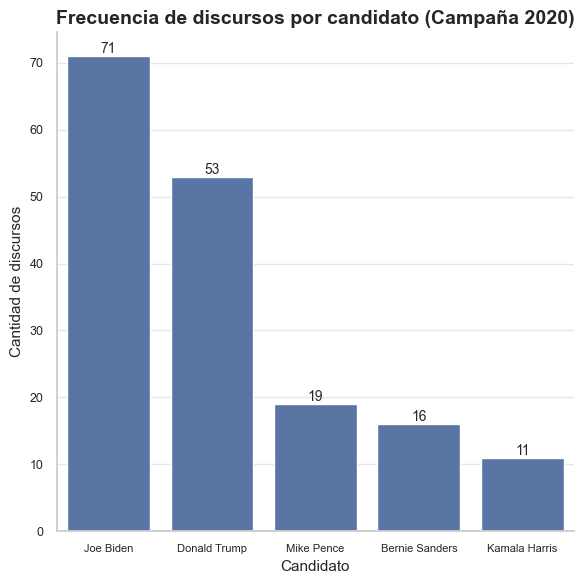

In [9]:

# Filtrar top 5 oradores
top_5_candidates = df_speeches_clean["speaker"].value_counts().head(5).index
data_top5 = df_speeches_clean[df_speeches_clean["speaker"].isin(top_5_candidates)]

# Crear figura
plt.figure(figsize=(6, 6))
ax = sns.countplot(data=data_top5, x="speaker", order=top_5_candidates)

# Títulos y etiquetas
plt.title("Frecuencia de discursos por candidato (Campaña 2020)", fontsize=14, weight='bold')
plt.xlabel("Candidato", fontsize=11)
plt.ylabel("Cantidad de discursos", fontsize=11)

# Mostrar valores sobre cada barra
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=10)

# Ajustar espaciado y estética
plt.xticks(fontsize=8)
plt.yticks(fontsize=9)
plt.grid(axis='y', alpha=0.5)
sns.despine()  # Elimina borde superior y derecho

plt.tight_layout()
plt.show()


In [10]:
# Filtramos los 3 candidatos con más discursos.
top_3_candidates = df_speeches_clean["speaker"].value_counts().head(3).index
print(f"Top 3 candidatos: {top_3_candidates}")
# print("---------------")

df_speeches_top_3 = df_speeches_clean[
     df_speeches_clean["speaker"].isin(top_3_candidates)
].reset_index(drop=True)
df_speeches_top_3

print(df_speeches_top_3.iloc[0, 2])

Top 3 candidatos: Index(['Joe Biden', 'Donald Trump', 'Mike Pence'], dtype='object', name='speaker')
hello michigan hi how are you what’s your name sam good to see you man thanks for being here i appreciate it alexia thank you for taking the time telling your story it’s important unfortunately there are an awful lot of stories like yours all over america as i travel the country too many it don’t have to be and folks it’s great to be back it’s great to be here there’s not a better governor in the united states of america than gretchen whitmer that’s a fact i’ve met virtually all of them and gary we badly need you back in the united states senate pal we badly need you back in the united states senate and then my sister debbie stabenow god love you debbie we worked so closely together for so long and as vice-president as well folks look we need to send gary back to another term standing up for michigan michigan families small businesses he was our main congressional partner back in 2010 w

## Parte 1: Dataset y representación numérica de texto

In [11]:
# 1: Separar 30% del conjunto para test. Al resto lo llamamos "dev" (desarrollo).

X_dev, X_test, y_dev, y_test = train_test_split(
    df_speeches_top_3["text"], 
    df_speeches_top_3["speaker"], 
    stratify=df_speeches_top_3["speaker"], 
    test_size=0.3, 
    random_state=42
)
print(f"Tamaños de los conjuntos: {df_speeches_top_3.shape}")
print(f"Conjunto de desarrollo: {X_dev.shape}, {X_test.shape}")

Tamaños de los conjuntos: (143, 6)
Conjunto de desarrollo: (100,), (43,)


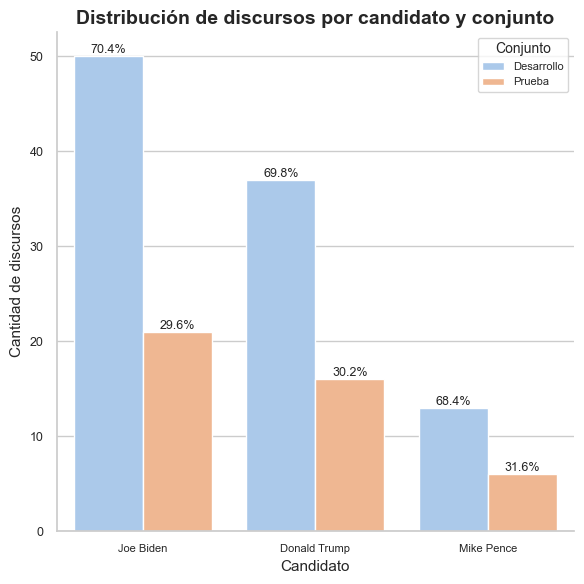

In [12]:
# 2: Visualización de la proporción de cada candidato por conjunto

def plot_candidate_distribution_relative(y_dev, y_test):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Unificar datos
    df_dev = pd.DataFrame({'candidato': y_dev, 'conjunto': 'Desarrollo'})
    df_test = pd.DataFrame({'candidato': y_test, 'conjunto': 'Prueba'})
    df = pd.concat([df_dev, df_test])

    # Selección de top 3 candidatos
    top_3_candidates = df['candidato'].value_counts().head(3).index
    df = df[df['candidato'].isin(top_3_candidates)]

    # Calcular proporciones relativas (cada fila suma 1)
    counts = df.groupby(['candidato', 'conjunto']).size().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0)

    # Graficar
    plt.figure(figsize=(6, 6))
    sns.set(style="whitegrid")
    ax = sns.countplot(data=df, x='candidato', hue='conjunto',
                       palette='pastel', order=top_3_candidates)

    # Anotar porcentaje relativo en cada barra
    for p in ax.patches:
        height = p.get_height()
        if height == 0:
            continue
        
        x = p.get_x() + p.get_width() / 2

        # Obtener valores de los ejes
        candidato = p.get_x() + p.get_width() / 2.
        grupo = p.get_label()  # no funciona, vamos manual

        # Alternativa: extraer texto del eje X y hue desde el objeto de la barra
        # Primero: obtener nombre del candidato (eje X)
        candidato_idx = int(p.get_x() + p.get_width() / 2)
        candidato_name = p.get_x() + p.get_width() / 2.

        # Alternativa segura: obtener valores desde la posición de la barra
        candidato = p.get_x() + p.get_width() / 2.
        # Pero mejor: usemos `get_x()` y `get_width()` para detectar el nombre con orden
        x_idx = round(p.get_x() + p.get_width() / 2.)
        candidato = ax.get_xticklabels()[x_idx].get_text()

        # Color define el conjunto (posición en leyenda)
        color = p.get_facecolor()
        conjunto = 'Desarrollo' if color == ax.patches[0].get_facecolor() else 'Prueba'

        # Extraer proporción
        try:
            porcentaje = proportions.loc[candidato, conjunto]
            ax.annotate(f'{porcentaje:.1%}',
                        (x, height),
                        ha='center', va='bottom', fontsize=9)
        except KeyError:
            continue  # Por si falta el dato

    # Estética
    plt.title('Distribución de discursos por candidato y conjunto', fontsize=14, weight='bold')
    plt.xlabel('Candidato', fontsize=11)
    plt.ylabel('Cantidad de discursos', fontsize=11)
    plt.legend(title='Conjunto', fontsize=8, title_fontsize=10)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    sns.despine()
    plt.show()

plot_candidate_distribution_relative(y_dev, y_test)

In [13]:
# 3: Transforme el texto del conjunto de entrenamiento a la representación numérica (features) de conteo de palabras o bag of words.

vectorizer = CountVectorizer(
    stop_words=None,
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1, 1))

X_dev_counts = vectorizer.fit_transform(X_dev)
print(f"Dimensiones de la matriz de conteo: {X_dev_counts.shape}")
print(f"Proporción de entradas no cero: {X_dev_counts.nnz / X_dev_counts.shape[0] / X_dev_counts.shape[1]}")


vectorizer2 = CountVectorizer(
    stop_words=stopwords.words("english"),
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1, 2))

X_dev_counts2 = vectorizer2.fit_transform(X_dev)

print(f"Dimensiones de la matriz de conteo: {X_dev_counts2.shape}")
print(f"Proporción de entradas no cero: {X_dev_counts2.nnz / X_dev_counts2.shape[0] / X_dev_counts2.shape[1]}")


Dimensiones de la matriz de conteo: (100, 13704)
Proporción de entradas no cero: 0.08890615878575597
Dimensiones de la matriz de conteo: (100, 197501)
Proporción de entradas no cero: 0.019658634639824608


In [14]:
# 4: Obtenga la representación numérica Term Frequency - Inverse Document Frequency.

X_dev_tfidf = TfidfTransformer(use_idf=True).fit_transform(X_dev_counts)
print(f"Dimensiones de la matriz TF-IDF: {X_dev_tfidf.shape}")

X_dev_tfidf2 = TfidfTransformer(use_idf=True).fit_transform(X_dev_counts2)

Dimensiones de la matriz TF-IDF: (100, 13704)


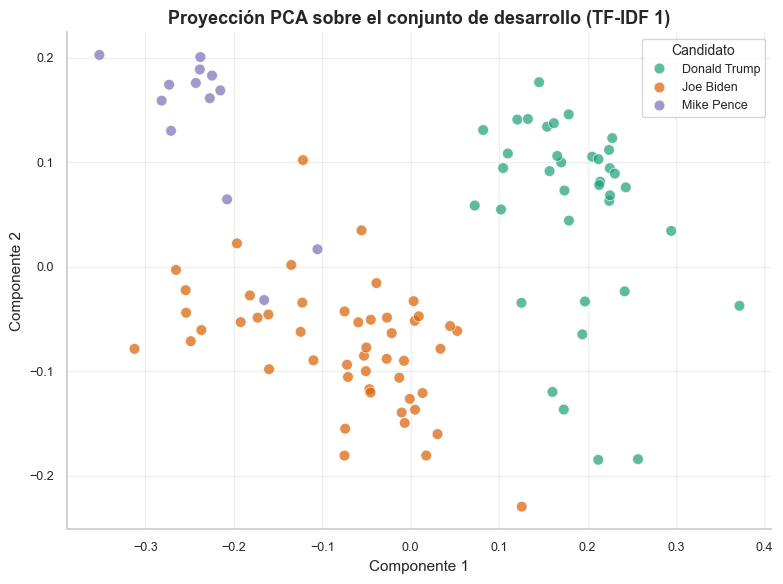

Varianza explicada por las dos primeras componentes (TF-IDF 2): 0.2079305227354573


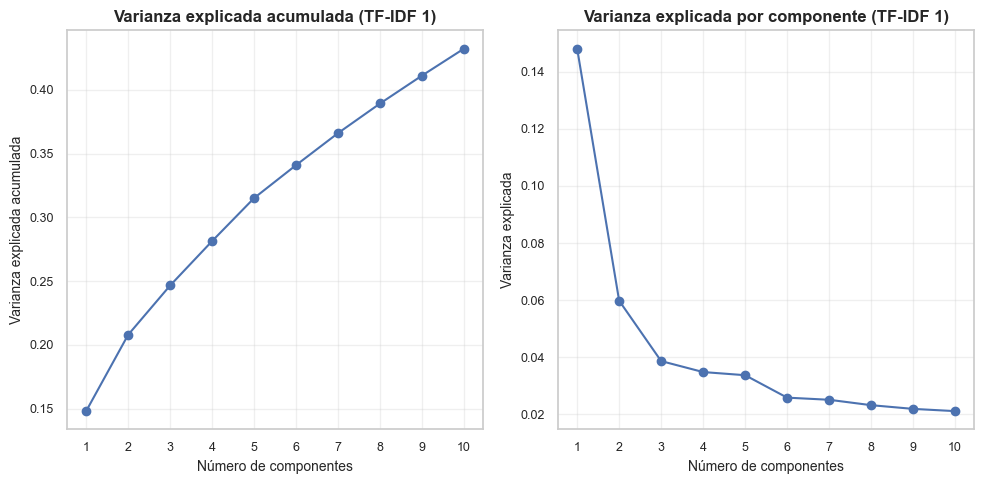

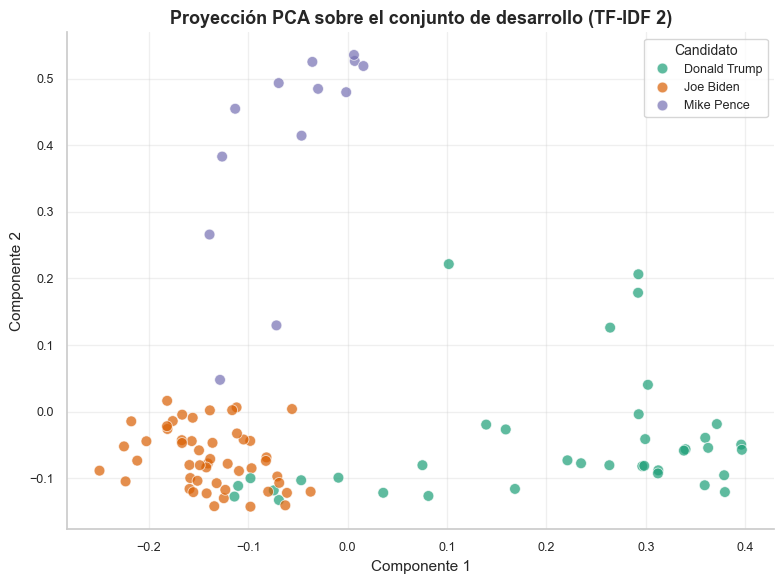

Varianza explicada por las dos primeras componentes (TF-IDF 2): 0.08078084171634328


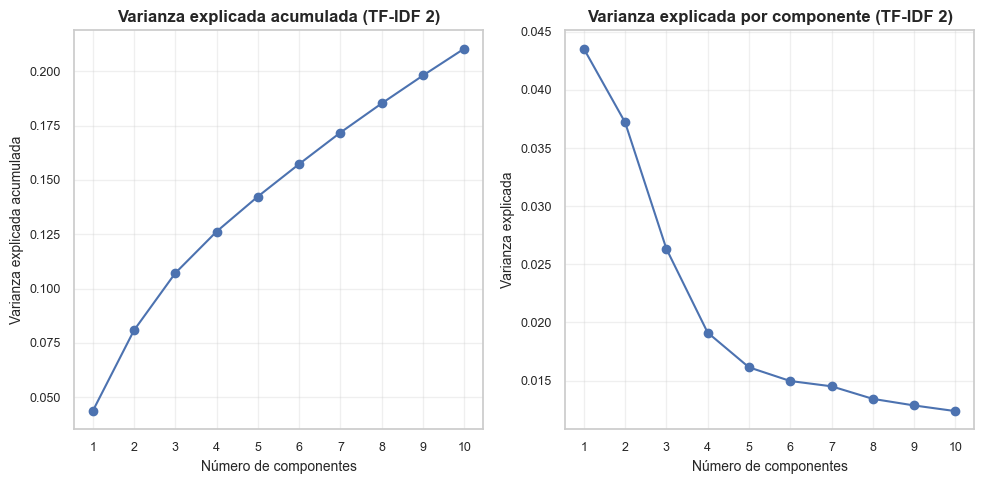

In [15]:
# 5 :Muestre en un mapa el conjunto de entrenamiento, utilizando las dos primeras componentes PCA sobre los vectores de tf-idf.

# PCA sobre X_dev_tfidf
pca = PCA(n_components=10)
X_dev_pca = pca.fit_transform(X_dev_tfidf.toarray())

# Gráfico PCA 2D
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")
ax = sns.scatterplot(
    x=X_dev_pca[:, 0],
    y=X_dev_pca[:, 1],
    hue=y_dev,
    palette="Dark2",
    alpha=0.7,
    s=60
)
plt.xlabel('Componente 1', fontsize=11)
plt.ylabel('Componente 2', fontsize=11)
plt.title('Proyección PCA sobre el conjunto de desarrollo (TF-IDF 1)', fontsize=13, weight='bold')
plt.legend(title='Candidato', fontsize=9, title_fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# print varianza explicada en las dos primeras componentes
print(f"Varianza explicada por las dos primeras componentes (TF-IDF 2): {np.sum(pca.explained_variance_ratio_[:2])}")

# Gráfico de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.set(style="whitegrid")

# Acumulada
axes[0].plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_[:10]), marker='o', linestyle='-')
axes[0].set_title('Varianza explicada acumulada (TF-IDF 1)', fontsize=12, weight='bold')
axes[0].set_xlabel('Número de componentes', fontsize=10)
axes[0].set_ylabel('Varianza explicada acumulada', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(1, 11))
axes[0].tick_params(labelsize=9)

# Individual
axes[1].plot(range(1, 11), pca.explained_variance_ratio_[:10], marker='o', linestyle='-')
axes[1].set_title('Varianza explicada por componente (TF-IDF 1)', fontsize=12, weight='bold')
axes[1].set_xlabel('Número de componentes', fontsize=10)
axes[1].set_ylabel('Varianza explicada', fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(range(1, 11))
axes[1].tick_params(labelsize=9)

plt.tight_layout()
plt.show()

# PCA sobre X_dev_tfidf2
pca2 = PCA(n_components=10)
X_dev_pca2 = pca2.fit_transform(X_dev_tfidf2.toarray())

# Gráfico PCA 2D
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")
ax = sns.scatterplot(
    x=X_dev_pca2[:, 0],
    y=X_dev_pca2[:, 1],
    hue=y_dev,
    palette="Dark2",
    alpha=0.7,
    s=60
)
plt.xlabel('Componente 1', fontsize=11)
plt.ylabel('Componente 2', fontsize=11)
plt.title('Proyección PCA sobre el conjunto de desarrollo (TF-IDF 2)', fontsize=13, weight='bold')
plt.legend(title='Candidato', fontsize=9, title_fontsize=10)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# print varianza explicada en las dos primeras componentes
print(f"Varianza explicada por las dos primeras componentes (TF-IDF 2): {np.sum(pca2.explained_variance_ratio_[:2])}")

# Gráfico de varianza explicada
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.set(style="whitegrid")

# Acumulada
axes[0].plot(range(1, 11), np.cumsum(pca2.explained_variance_ratio_[:10]), marker='o', linestyle='-')
axes[0].set_title('Varianza explicada acumulada (TF-IDF 2)', fontsize=12, weight='bold')
axes[0].set_xlabel('Número de componentes', fontsize=10)
axes[0].set_ylabel('Varianza explicada acumulada', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_xticks(range(1, 11))
axes[0].tick_params(labelsize=9)

# Individual
axes[1].plot(range(1, 11), pca2.explained_variance_ratio_[:10], marker='o', linestyle='-')
axes[1].set_title('Varianza explicada por componente (TF-IDF 2)', fontsize=12, weight='bold')
axes[1].set_xlabel('Número de componentes', fontsize=10)
axes[1].set_ylabel('Varianza explicada', fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(range(1, 11))
axes[1].tick_params(labelsize=9)

plt.tight_layout()
plt.show()


En esta sección se exploran los efectos de aplicar un Análisis de Componentes Principales (PCA) sobre los vectores de frecuencia TF-IDF, con el objetivo de evaluar si es posible discriminar entre discursos pertenecientes a diferentes candidatos presidenciales.

La visualización de los datos proyectados sobre las dos primeras componentes principales revela una separación parcial pero significativa entre los discursos de Donald Trump, Joe Biden y Mike Pence. A pesar de que estas dos componentes retienen una fracción limitada de la varianza total (~21 % para la primera representación TF-IDF, veáse figura __), los discursos tienden a agruparse por autor, lo cual sugiere que existen diferencias sistemáticas en el vocabulario y el estilo discursivo que el PCA logra capturar en el subespacio reducido. La figura __ muestra los clústeres resultantes, a la derecha con respecto a la primer componente, se puede identificar que los discursos que caen por encima de 0.75 corresponden mayoritariemnte a Trump y que además los discursos forman una nube que aumenta su dispersión a medida que se disminuye en la componente 2. Con respecto a Biden, sus discursos se agrupan en la parte inferior izquierda y central del gráfico, mientras que los discursos de Pence se sitúan en la parte superior izquierda, lo que indica una separación entre los estilos de estos dos candidatos aunque comparten ciertas similitudes.

En una segunda versión del análisis PCA, se aplicaron dos modificaciones clave sobre el BoW: i) la eliminación de stopwords en inglés; y ii) la adición de bigramas al vocabulario.

La eliminación de stopwords contribuye a reducir el ruido introducido por términos frecuentes y semánticamente vacíos (como "the", "and", "of"), mejorando la capacidad del modelo para centrarse en términos informativos. Por su parte, la inclusión de bigramas enriquece el modelo al capturar expresiones características de cada candidato, tales como "middle class", "great again", o "health care", lo cual aporta contexto adicional a los unigramas aislados.

Curiosamente, la nueva representación (TF-IDF 2) explica una menor proporción de la varianza total en sus primeras dos componentes aproximadamente ~9 % (figura __ ), esto se explica por el aumento del tamaño del vocabulario y, en consecuencia, de la dimensionalidad. Esta nueva representación requiere de al menos 10 componentes para explicar la misma varianza que en la representación primera (figura ___). Sin embargo, esta pérdida de varianza acumulada no compromete la capacidad discriminativa: de hecho, obervando la figura __ con la representación de las primeras dos componentes, los clústeres por candidato aparecen incluso mejor definidos, lo que sugiere que las nuevas dimensiones, aunque más dispersas, contienen señales útiles para distinguir autores.

Finalmente, se espera que la omisión del filtrado de signos de puntuación tenga un efecto relevante en la representación; causando la introducción de tokens adicionales (como "economy." o "freedom,"), los cuales resultarán poco frecuentes en comparación a la misma palabra sin el signo de puntuación ("economy", "freedom"), recibiendo asi, bajo peso en la representación de la matriz TF-IDF, por lo que disminuiría la varianza explicada en las primeras componentes.

En síntesis, los resultados muestran que el PCA, combinado con una representación semánticamente informativa del texto, permite capturar diferencias estilísticas relevantes entre los discursos de campaña. Esto valida su utilidad como herramienta exploratoria previa a tareas de clasificación o modelado supervisado.



## Parte 2: Entrenamiento y Evaluación de Modelos


Accuracy del modelo Naive Bayes: 1.00


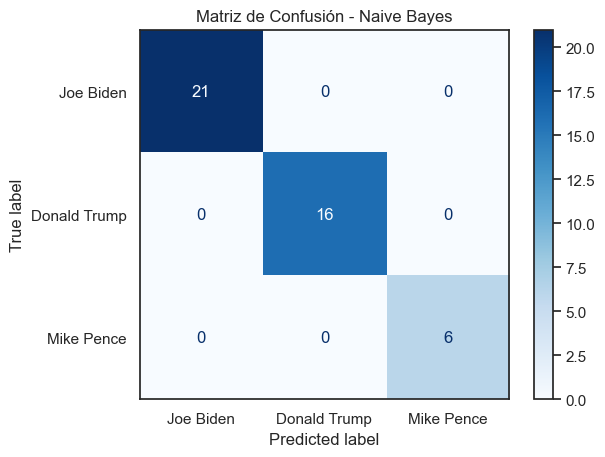

Candidato: Joe Biden, Precision: 1.00, Recall: 1.00
Candidato: Donald Trump, Precision: 1.00, Recall: 1.00
Candidato: Mike Pence, Precision: 1.00, Recall: 1.00


In [ ]:
# 1: Entrene el modelo Multinomial Naive Bayes, luego utilícelo para predecir sobre el conjunto de test, y reporte el valor de accuracy y la matriz de confusión. Reporte el valor de precision y recall para cada candidato. 
# Calcular matriz de confusión Sugerencia: utilice el método from_predictions de ConfusionMatrixDisplay para realizar la matriz.

# Entrenamiento del modelo Multinomial Naive Bayes
nb_model = MultinomialNB(alpha=1, fit_prior=True)
nb_model.fit(X_dev_tfidf, y_dev)

# Predicción sobre el conjunto de test
X_test_tfidf = TfidfTransformer().fit_transform(vectorizer.transform(X_test))
y_pred = nb_model.predict(X_test_tfidf)

# set sns set to none
sns.set(style="white")  # Fondo blanco sin grilla

# Reporte de accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo Naive Bayes: {accuracy:.2f}")
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=top_3_candidates)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_3_candidates)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Naive Bayes')
plt.show()
# Reporte de precision y recall
precision = precision_score(y_test, y_pred, average=None, labels=top_3_candidates)
recall = recall_score(y_test, y_pred, average=None, labels=top_3_candidates)
for candidate, prec, rec in zip(top_3_candidates, precision, recall):
    print(f"Candidato: {candidate}, Precision: {prec:.2f}, Recall: {rec:.2f}")

Mejores parámetros encontrados:
{'alpha': 0.001, 'fit_prior': True}


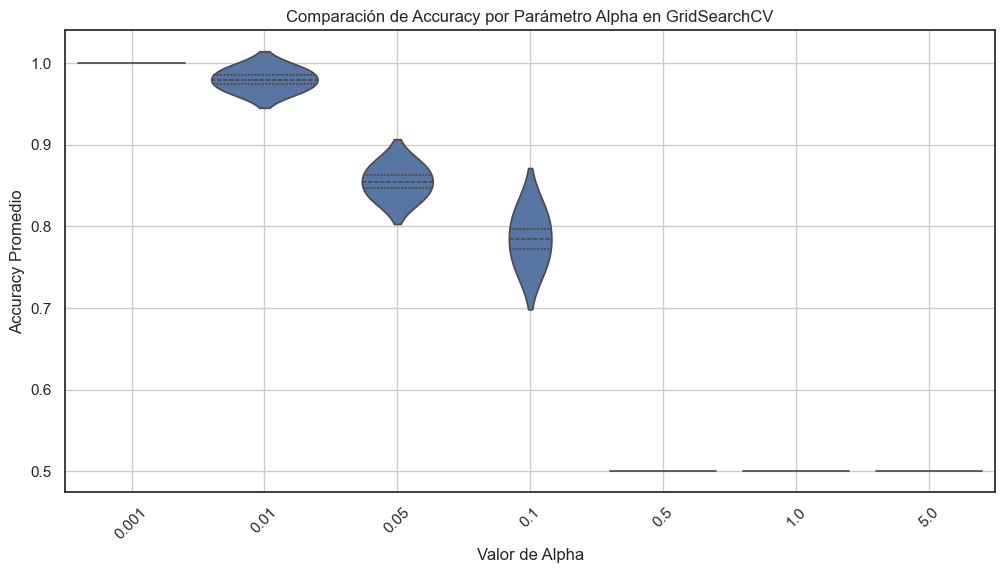

In [ ]:
# 2: Implemente una búsqueda de hiperparámetros usando GridSearchCV.

GridSearchCV_params = {
    'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0],
    'fit_prior': [True, False]
}
grid_search = GridSearchCV(
    MultinomialNB(),
    param_grid=GridSearchCV_params,
    scoring='accuracy',
    cv=5,
    verbose=0,
    n_jobs=-1
)
grid_search.fit(X_dev_tfidf, y_dev)
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

# Genere una visualización que permita comparar las métricas (e.g: accuracy) de los distintos modelos entrenados, viendo el valor promedio y variabilidad de las mismas en todos los splits (e.g: en un gráfico de violín).
violin_data = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(12, 6))
sns.violinplot(x='param_alpha', y='mean_test_score', data=violin_data, inner='quartile')
plt.title('Comparación de Accuracy por Parámetro Alpha en GridSearchCV')
plt.xlabel('Valor de Alpha')
plt.ylabel('Accuracy Promedio')
plt.xticks(rotation=45)
plt.grid()
plt.show()


Accuracy del modelo Naive Bayes: 1.00


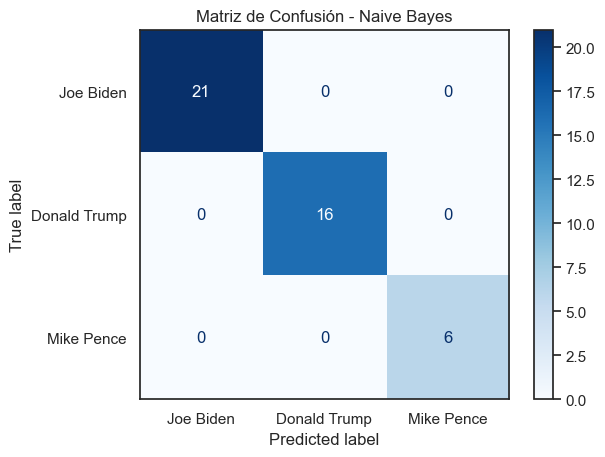

Candidato: Joe Biden, Precision: 1.00, Recall: 1.00
Candidato: Donald Trump, Precision: 1.00, Recall: 1.00
Candidato: Mike Pence, Precision: 1.00, Recall: 1.00


In [34]:
# entrenamiento del modelo Multinomial Naive Bayes bajo el resultado de GridSearchCV
nb_model = MultinomialNB(alpha=0.01, fit_prior=True)
nb_model.fit(X_dev_tfidf, y_dev)

# Predicción sobre el conjunto de test
X_test_tfidf = TfidfTransformer().fit_transform(vectorizer.transform(X_test))
y_pred = nb_model.predict(X_test_tfidf)

# set sns set to none
sns.set(style="white")  # Fondo blanco sin grilla

# reporte de accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo Naive Bayes: {accuracy:.2f}")
# matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=top_3_candidates)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_3_candidates)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Naive Bayes')
plt.show()

# reporte de precision y recall
precision = precision_score(y_test, y_pred, average=None, labels=top_3_candidates)
recall = recall_score(y_test, y_pred, average=None, labels=top_3_candidates)
for candidate, prec, rec in zip(top_3_candidates, precision, recall):
    print(f"Candidato: {candidate}, Precision: {prec:.2f}, Recall: {rec:.2f}")

In [ ]:
# 3: Elija el mejor modelo (mejores parámetros) y vuelva a entrenar sobre todo el conjunto de entrenamiento disponible (sin quitar datos para validación). Reporte el valor final de las métricas y la matriz de confusión.


Accuracy del modelo Naive Bayes: 0.84


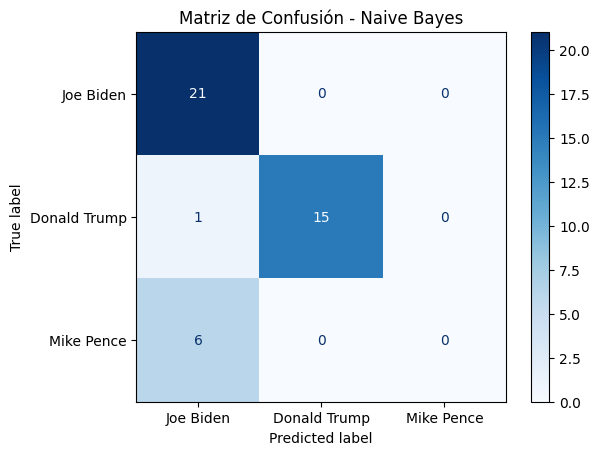

Candidato: Joe Biden, Precision: 0.75, Recall: 1.00
Candidato: Donald Trump, Precision: 1.00, Recall: 0.94
Candidato: Mike Pence, Precision: 0.00, Recall: 0.00


c:\Users\campo\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# 4: Evalúe con validación cruzada al menos un modelo más (dentro de scikit-learn) aparte de Multinomial Naive Bayes para clasificar el texto utilizando las mismas features de texto.
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_dev_tfidf, y_dev)
y_pred = model_lr.predict(X_test_tfidf)

# Reporte de accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo Logistic Regression: {accuracy:.2f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=top_3_candidates)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_3_candidates)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Logistic Regression')
plt.show()

# Reporte de precision y recall
precision = precision_score(y_test, y_pred, average=None, labels=top_3_candidates)
recall = recall_score(y_test, y_pred, average=None, labels=top_3_candidates)
for candidate, prec, rec in zip(top_3_candidates, precision, recall):
    print(f"Candidato: {candidate}, Precision: {prec:.2f}, Recall: {rec:.2f}")


Top 3 candidatos: Index(['Joe Biden', 'Donald Trump', 'Kamala Harris'], dtype='object', name='speaker')
Tamaños de los conjuntos: (135, 6)
Tamaños de los conjuntos: (94,), (41,)
['Kamala Harris' 'Joe Biden' 'Donald Trump']


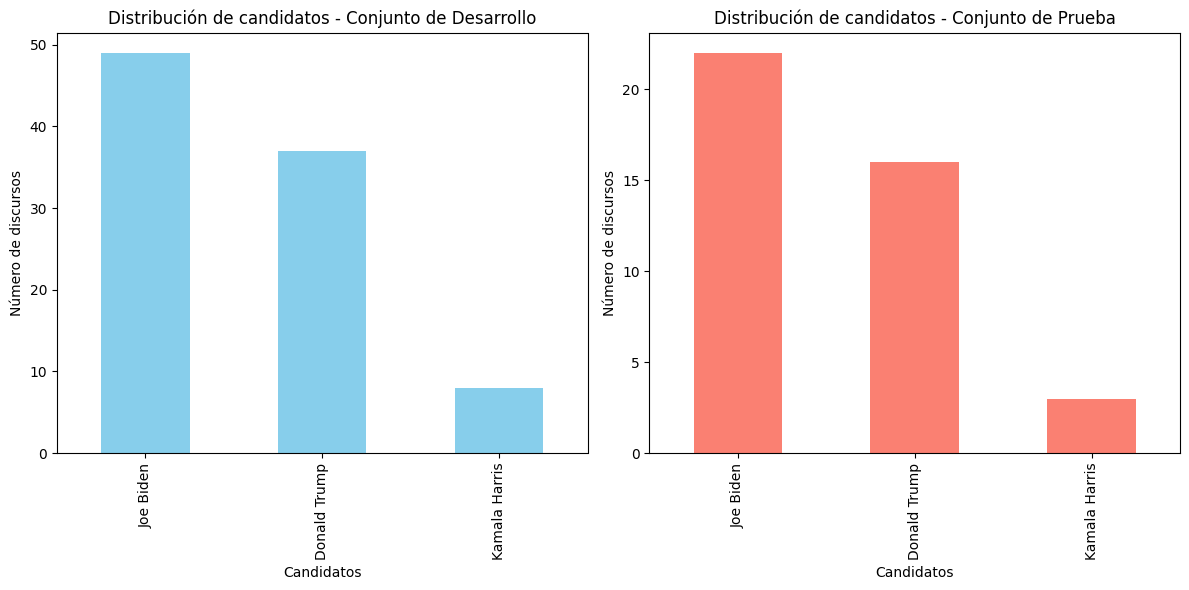

Dimensiones de la matriz de conteo: (94, 13752)
Proporción de entradas no cero: 0.08906248066045325
Dimensiones de la matriz de conteo: (94, 194538)
Proporción de entradas no cero: 0.020256502968407638
Dimensiones de la matriz TF-IDF: (94, 13752)


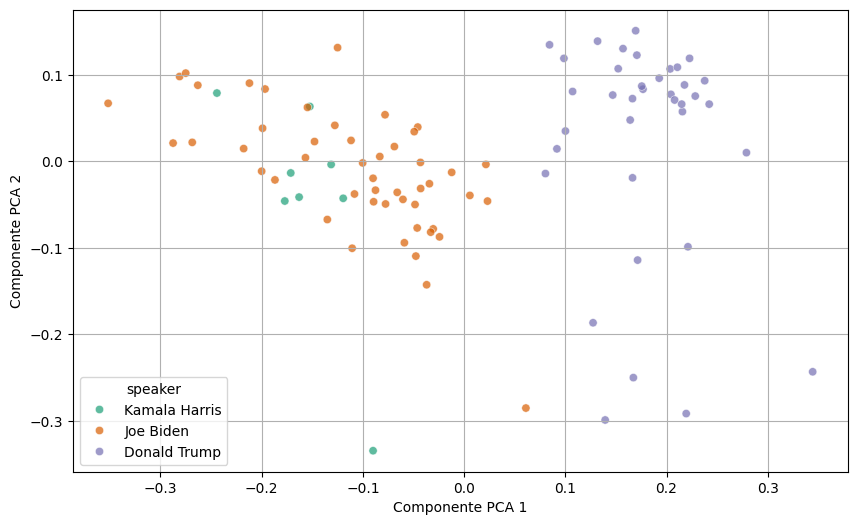

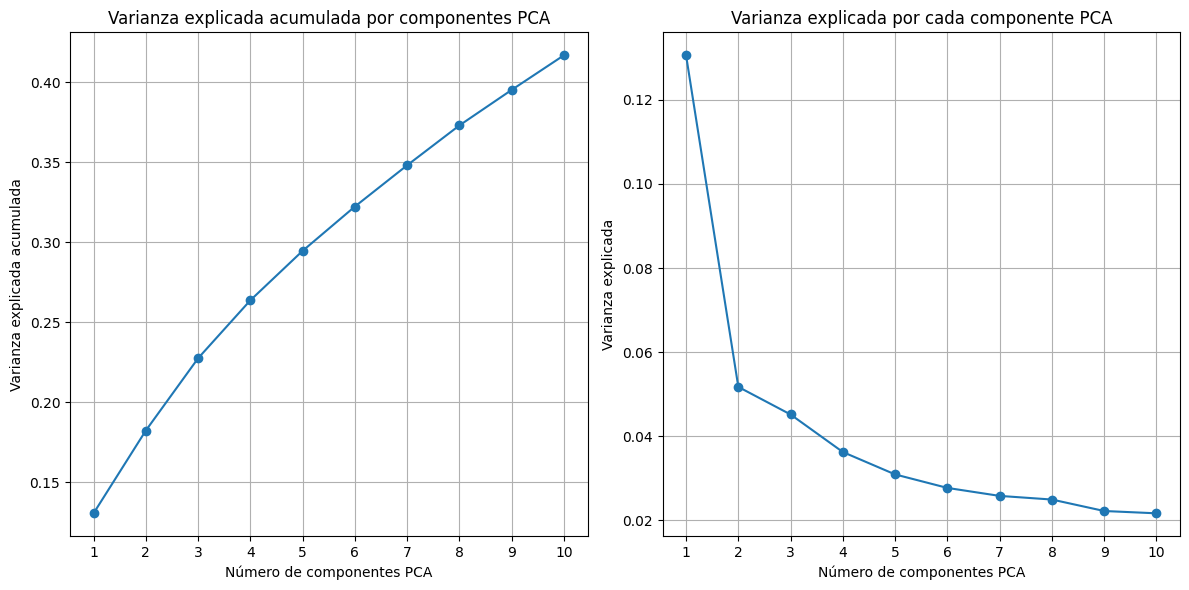

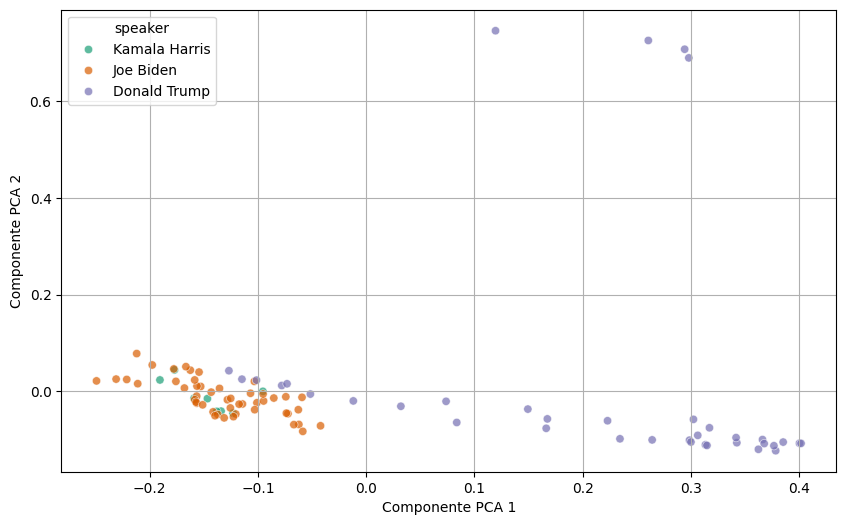

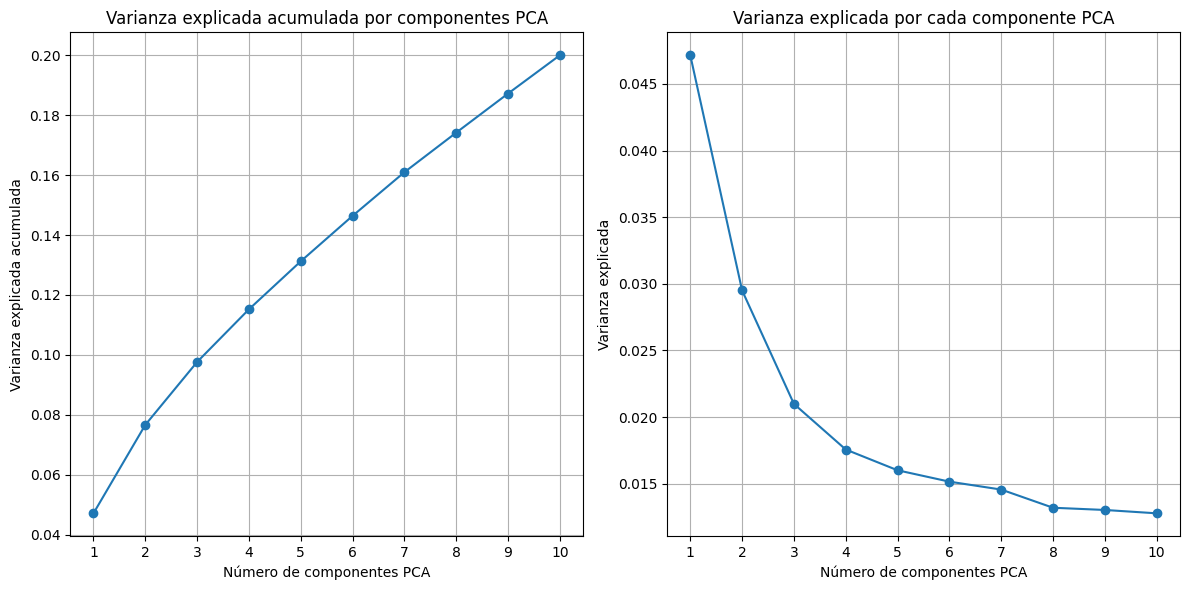

In [ ]:
# 5: Evalúe el problema cambiando al menos un candidato. En particular, observe el (des)balance de datos y los problemas que pueda generar, así como cualquier indicio que pueda ver en el mapeo previo con PCA.
top_3_candidates = df_speeches_clean["speaker"].value_counts().head(5).index
# descartamos al tercer candidato
top_3_candidates = top_3_candidates.drop(top_3_candidates[2])
top_3_candidates = top_3_candidates.drop(top_3_candidates[2])
print(f"Top 3 candidatos: {top_3_candidates}")
# print("---------------")

df_speeches_top_3 = df_speeches_clean[
     df_speeches_clean["speaker"].isin(top_3_candidates)
].reset_index(drop=True)


# 1: Separar 30% del conjunto para test. Al resto lo llamamos "dev" (desarrollo).

X_dev, X_test, y_dev, y_test = train_test_split(
    df_speeches_top_3["text"], 
    df_speeches_top_3["speaker"], 
    stratify=df_speeches_top_3["speaker"], 
    test_size=0.3, 
    random_state=42
)
print(f"Tamaños de los conjuntos: {df_speeches_top_3.shape}")
print(f"Tamaños de los conjuntos: {X_dev.shape}, {X_test.shape}")
print(y_dev.unique())


# 2: Visualización de la proporción de cada candidato por conjunto

import matplotlib.pyplot as plt

def plot_candidate_distribution(y_dev, y_test):
    plt.figure(figsize=(12, 6))

    # Gráfico de barras para el conjunto de desarrollo
    plt.subplot(1, 2, 1)
    y_dev.value_counts().plot(kind='bar', color='skyblue')
    plt.title('Distribución de candidatos - Conjunto de Desarrollo')
    plt.xlabel('Candidatos')
    plt.ylabel('Número de discursos')

    # Gráfico de barras para el conjunto de prueba
    plt.subplot(1, 2, 2)
    y_test.value_counts().plot(kind='bar', color='salmon')
    plt.title('Distribución de candidatos - Conjunto de Prueba')
    plt.xlabel('Candidatos')
    plt.ylabel('Número de discursos')

    plt.tight_layout()
    plt.show()

plot_candidate_distribution(y_dev, y_test)


# 3: Transforme el texto del conjunto de entrenamiento a la representación numérica (features) de conteo de palabras o bag of words.

vectorizer = CountVectorizer(
    stop_words=None,
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1, 1)
    
)

X_dev_counts = vectorizer.fit_transform(X_dev)
print(f"Dimensiones de la matriz de conteo: {X_dev_counts.shape}")
print(f"Proporción de entradas no cero: {X_dev_counts.nnz / X_dev_counts.shape[0] / X_dev_counts.shape[1]}")
vectorizer2 = CountVectorizer(
    stop_words=stopwords.words("english"),
    lowercase=True,
    token_pattern=r"(?u)\b\w+\b",
    ngram_range=(1, 2)
    
)

X_dev_counts2 = vectorizer2.fit_transform(X_dev)

print(f"Dimensiones de la matriz de conteo: {X_dev_counts2.shape}")
print(f"Proporción de entradas no cero: {X_dev_counts2.nnz / X_dev_counts2.shape[0] / X_dev_counts2.shape[1]}")


# 4: Obtenga la representación numérica Term Frequency - Inverse Document Frequency.

X_dev_tfidf = TfidfTransformer(use_idf=True).fit_transform(X_dev_counts)
print(f"Dimensiones de la matriz TF-IDF: {X_dev_tfidf.shape}")

X_dev_tfidf2 = TfidfTransformer(use_idf=True).fit_transform(X_dev_counts2)


# 5 :Muestre en un mapa el conjunto de entrenamiento, utilizando las dos primeras componentes PCA sobre los vectores de tf-idf.

pca = PCA(n_components=10)
X_dev_pca = pca.fit_transform(X_dev_tfidf.toarray())

# Visualización de las dos primeras componentes PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_dev_pca[:, 0], 
    y=X_dev_pca[:, 1], 
    hue=y_dev, 
    palette='Dark2', 
    alpha=0.7
)
plt.xlabel('Componente PCA 1')
plt.ylabel('Componente PCA 2')
plt.grid()
plt.show()

# Haga una visualización que permita entender cómo varía la varianza explicada a medida que se agregan componentes (e.g: hasta 10 cplt.figure(figsize=(10, 6))
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Primer gráfico: varianza explicada acumulada
axes[0].plot(range(1, 11), np.cumsum(pca.explained_variance_ratio_[:10]), marker='o')
axes[0].set_title('Varianza explicada acumulada por componentes PCA')
axes[0].set_xlabel('Número de componentes PCA')
axes[0].set_ylabel('Varianza explicada acumulada')
axes[0].grid()
axes[0].set_xticks(range(1, 11))

# Segundo gráfico: varianza explicada individual
axes[1].plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, marker='o')
axes[1].set_title('Varianza explicada por cada componente PCA')
axes[1].set_xlabel('Número de componentes PCA')
axes[1].set_ylabel('Varianza explicada')
axes[1].grid()
axes[1].set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))

plt.tight_layout()
plt.show()

pca2 = PCA(n_components=10)
X_dev_pca2 = pca2.fit_transform(X_dev_tfidf2.toarray())

# Visualización de las dos primeras componentes PCA
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_dev_pca2[:, 0], 
    y=X_dev_pca2[:, 1], 
    hue=y_dev, 
    palette='Dark2', 
    alpha=0.7
)
plt.xlabel('Componente PCA 1')
plt.ylabel('Componente PCA 2')
plt.grid()
plt.show()

# Haga una visualización que permita entender cómo varía la varianza explicada a medida que se agregan componentes (e.g: hasta 10 cplt.figure(figsize=(10, 6))
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Primer gráfico: varianza explicada acumulada
axes[0].plot(range(1, 11), np.cumsum(pca2.explained_variance_ratio_[:10]), marker='o')
axes[0].set_title('Varianza explicada acumulada por componentes PCA')
axes[0].set_xlabel('Número de componentes PCA')
axes[0].set_ylabel('Varianza explicada acumulada')
axes[0].grid()
axes[0].set_xticks(range(1, 11))

# Segundo gráfico: varianza explicada individual
axes[1].plot(range(1, len(pca2.explained_variance_ratio_) + 1), pca2.explained_variance_ratio_, marker='o')
axes[1].set_title('Varianza explicada por cada componente PCA')
axes[1].set_xlabel('Número de componentes PCA')
axes[1].set_ylabel('Varianza explicada')
axes[1].grid()
axes[1].set_xticks(range(1, len(pca2.explained_variance_ratio_) + 1))

plt.tight_layout()
plt.show()


In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_tfidf, y)


ModuleNotFoundError: No module named 'imblearn'

In [ ]:
# OPCIONAL: Repetir la clasificación con los tres candidatos con más discursos, pero esta vez clasificando a nivel de párrafos y no de discursos enteros.
